In [1]:
%%capture
%pip install -q easyocr "paddleocr>=2.0.1" paddlepaddle "python-doctr[torch]" opencv-python-headless pillow matplotlib pandas

In [2]:
%%capture
%pip install -q --upgrade --force-reinstall --no-cache-dir "numpy>=2.0" "pandas>=2.2"

In [3]:
# %% [A] traQ fetch (messages + images) + save images
import os, re, io
import requests
from PIL import Image
import getpass

messageIds = [
    "019b2a64-eebc-7815-84c5-e384fabc495c",
    "019a48ff-b175-783c-93fc-b4ec6731dde5",
    "019bb6b8-5c57-7d1f-8b93-297c8e6c7827",
    "019bb5c0-5409-7b3b-ba9b-07449030364a",
    "019bd043-d86c-79b8-9cf1-11351a482267",
    "0197c4ef-8be2-792e-922b-c498b6948775",
    "01963951-0f55-75b5-a53b-07f467ad9051",
    "0195be37-dea6-7902-8d04-e46185873108",
    "019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa",
    "019bde55-b166-7d7b-b290-2f049f72fe08",
    "019bbd0d-5e27-77b2-8494-42499697c033",
    "019bde84-1609-7dc5-b8fc-f2c77bcdb005",
    "019bdeb4-6ec8-7e0e-b773-3bec85c35584",
    "019bb65e-9263-7c89-b123-95389f4414cd",
    "019b8cea-695d-7047-aafb-793c58d25eff",
]

# 入力を隠す（おすすめ）
r_session = getpass.getpass("r_session を入力してください（表示されません）: ").strip()
if not r_session:
    raise RuntimeError("r_session が空です")

BASE_URL = "https://q.trap.jp/api/v3"
_FILE_URL_RE = re.compile(r"https?://q\.trap\.jp/files/([0-9a-fA-F-]+)")

def _get_session() -> requests.Session:
    s = requests.Session()
    s.cookies.set("r_session", r_session)
    return s

def get_messages_and_images(message_ids):
    messages, images = [], []
    with _get_session() as session:
        for mid in message_ids:
            resp = session.get(f"{BASE_URL}/messages/{mid}")
            resp.raise_for_status()
            content = resp.json()["content"]

            file_ids = _FILE_URL_RE.findall(content)
            imgs = []
            for fid in file_ids:
                r = session.get(f"{BASE_URL}/files/{fid}")
                r.raise_for_status()
                try:
                    imgs.append(Image.open(io.BytesIO(r.content)).convert("RGB"))
                except Exception as e:
                    # 非画像（pdf等）が混ざってたらスキップ
                    print(f"[skip] not an image fileId={fid}: {e}")

            text = _FILE_URL_RE.sub("", content).strip()
            messages.append(text)
            images.append(imgs)

    return messages, images

messages, images = get_messages_and_images(messageIds)
print("messages:", len(messages))
print("msgs with images:", sum(1 for x in images if len(x) > 0))

# 画像をローカルに保存して「処理対象リスト」を作る
SAVE_DIR = "/content/traq_images"
os.makedirs(SAVE_DIR, exist_ok=True)

records = []  # 1画像=1レコード
for mid, msg_text, imgs in zip(messageIds, messages, images):
    for j, im in enumerate(imgs):
        path = os.path.join(SAVE_DIR, f"{mid}_{j}.png")
        im.save(path)
        records.append({
            "messageId": mid,
            "image_index": j,
            "message_text": msg_text,
            "image_path": path,
        })

print("saved images:", len(records))
print("example:", records[0] if records else None)

messages: 15
msgs with images: 15
saved images: 20
example: {'messageId': '019b2a64-eebc-7815-84c5-e384fabc495c', 'image_index': 0, 'message_text': ':tada: 味処まるたかエグい\nhttps://icttoracon.net/archives/10329', 'image_path': '/content/traq_images/019b2a64-eebc-7815-84c5-e384fabc495c_0.png'}


In [6]:
# %% [B] OCR init
import time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import easyocr
from paddleocr import PaddleOCR
from doctr.io import DocumentFile
from doctr.models import ocr_predictor

# 言語切替
LANG_MODE = "ja"   # "en" or "ja"
EASYOCR_LANGS = ["en"] if LANG_MODE == "en" else ["ja", "en"]
PADDLE_LANG = "en" if LANG_MODE == "en" else "japan"

# init
easy_reader = easyocr.Reader(EASYOCR_LANGS, gpu=False, download_enabled=True)
from paddleocr import PaddleOCR

# v3系(=新API)なら use_textline_orientation が効く。v2系なら TypeError になるので自動で旧式にフォールバック。
try:
    paddle_ocr = PaddleOCR(
        lang=PADDLE_LANG,
        use_doc_orientation_classify=False,
        use_doc_unwarping=False,
        use_textline_orientation=True,  # v3推奨（角度/向き）
    )
except TypeError:
    paddle_ocr = PaddleOCR(
        use_angle_cls=True,  # v2系（旧）
        lang=PADDLE_LANG,
    )

print("PaddleOCR init OK")
doctr_ocr = ocr_predictor(pretrained=True)

print("OCR engines initialized.")

Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv5_server_rec`.


PaddleOCR init OK
OCR engines initialized.



[1/20] messageId=019b2a64-eebc-7815-84c5-e384fabc495c image_index=0
message_text (head): :tada: 味処まるたかエグい https://icttoracon.net/archives/10329
image_path: /content/traq_images/019b2a64-eebc-7815-84c5-e384fabc495c_0.png


,engine,seconds,n_items,mean_conf
2,doctr,1.403672,59,0.656822
0,easyocr,2.598650,48,0.932671
1,paddleocr,35.741934,49,0.988810


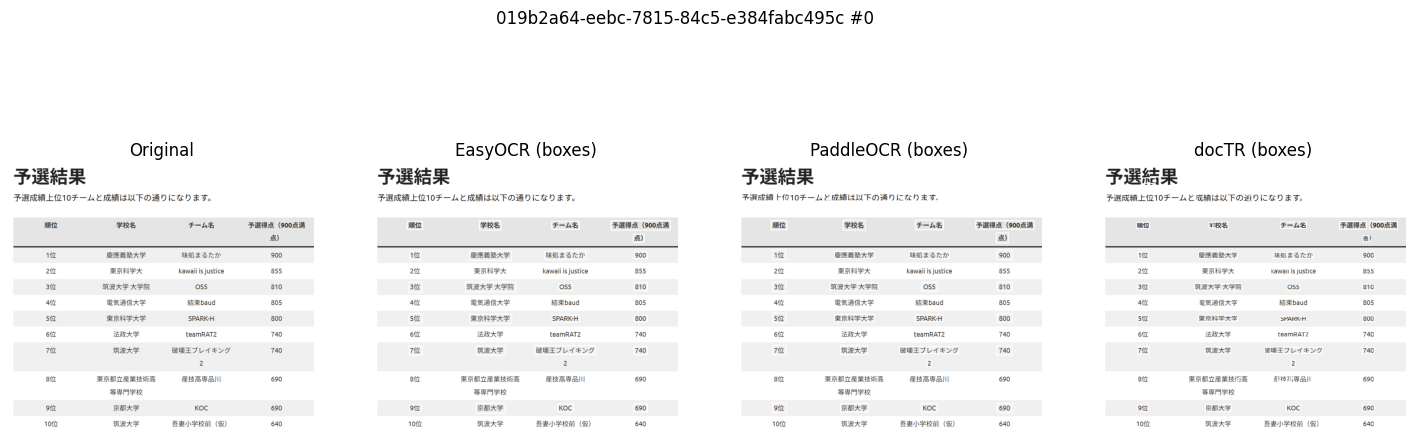


--- EasyOCR text preview ---
 予選結果
予選成績上位10チームと成績は以下の通りになります。
順位
学校名
チーム名
予選得点 (9の点満
点)
1位
慶雁義整大学
味処まるたか
900
2位
東京科学大
kawaiiisjustice
855
3位
筑波大学大学院
055
810
4位
電気通信大学
結束baud
805
5位
東京科学大学
SPARK-H
800
6位
法政大学
EeamRATZ
740
7位
筑波大学
破壊王ブレイキング
740
8位
東京都立産業技術高
産技高専品川
690
等専門学校
9位
京都大学
KoC
690
10位
筑波大学
吾妻小学校前
640

--- PaddleOCR text preview ---
 予選結果
予選成績上位10チ一ムと成績は以下の通りになります。
順位
学校名
チーム名
予選得点(900点满
点
1位
慶應義塾大学
味処まるたか
900
2位
東京科学大
kawaii is justice
855
3位
筑波大学大学院
OS5
810
4位
電気通信大学
結束baud
805
5位
東京科学大学
SPARK-H
800
6位
法政大学
teamRAT2
740
7位
筑波大学
破壊王ブレイキング
740
2
8位
東京都立產業技术高
産技高専品川
690
等専門学校
9位
京都大学
KOC
690
10位
筑波大学
吾妻小学校前 (仮)
640

--- docTR text preview ---
 D TAE1107-A C AEATO DEEDE9 JETL 7 KE F-48 FHH (900 E 117 EEEREAT RAL #otb 900 21 RRN7K kawail is justice 855 3117 FRATATL OS5 810 417 EXUHEXT baud 805 511 RRN7A7 SPARK-H 800 617 RETT teamRATZ 740 717 IRA7 RE7L1FV? 740 2 817 D EXE AAI 690 FU7K 9117 REBT7 KOC 690 10117 RtT 1217KE (12) 640

[2/20] messageId=019a48ff-b175-783c-93fc-b4ec6731dde5

,engine,seconds,n_items,mean_conf
2,doctr,1.642749,64,0.745862
0,easyocr,5.661808,48,0.438236
1,paddleocr,28.559957,36,0.816676


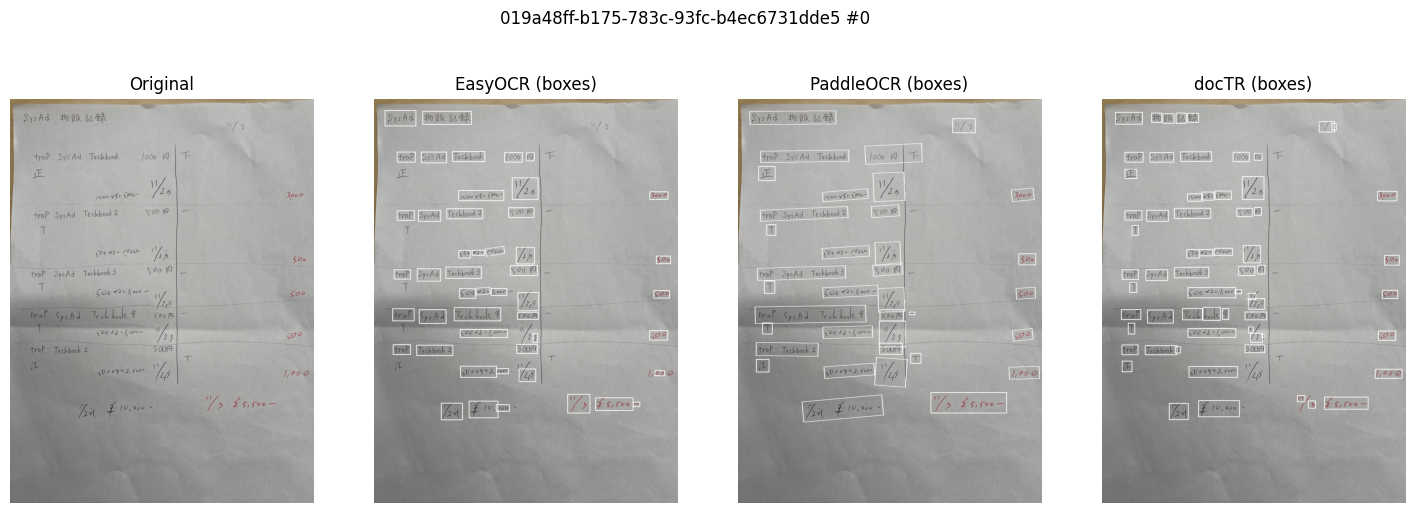


--- EasyOCR text preview ---
 SysAd
物販記録
trap
SysAd
Techbook
looo
1
(Oひ xXS 59v-
Is
3poこ
trap
SysAd
Techbook?
50 円
5ひ
メ)=
ln
5o。
trp
SysAd
Techbook3
50o 旧
5od
lvoo
5oo
Wi
fral
SysAd
てechhoolc 4
Soo円
5oo メ2-小・ひ一
5o0
1
trap
Techbook 2
50U
5ひ0xq-2
Vひり-
00
l4ら
#l,-
ooり
ツ,
#sso
一
小
ノ・・c_
x_=

--- PaddleOCR text preview ---
 SysAd物販記録
11/3
1000四下
traP SysAd Techbook
正
$1\{
1000×5=5000-
3,000
500円
traP SysAd Techbook2
T
/2
520×2=1000-
500
500
traP SysAd Techbook3
T
500×2=1,000-

500
tral Sys Ad Techboolc4
500円
一
T
/2
500×2=1,000-
500
traP Techbook2
500円
十
正
4
500×4=2,000-
1,000
"/3￥5,500-
7it ￥10,000

--- docTR text preview ---
 SysAd #n E 2 L7e 3 3 trap SysAd Techbook 1000 19 IF X3e Spou- V25 1000 3000 troP SysAd Techbook2 500 1 T SCO X)= r000- Xi 500 trap SysAd Techbook3 500 1 1 500x1-1,000 ( V/ 50o 125 tral SysAd Tech hoolc 4 5001 T 500K2-1,000- ( 12 / 500 trap Techbook 2 500R E 500X9-2,000- 1000 11 3 5500 Xx f10,000

[3/20] messageId=019bb6b8-5c57-7d1f-8b93-297c8e6c7827 image_index=0
mes

,engine,seconds,n_items,mean_conf
2,doctr,0.888392,25,0.658940
0,easyocr,8.476011,15,0.371723
1,paddleocr,27.890921,13,0.908042


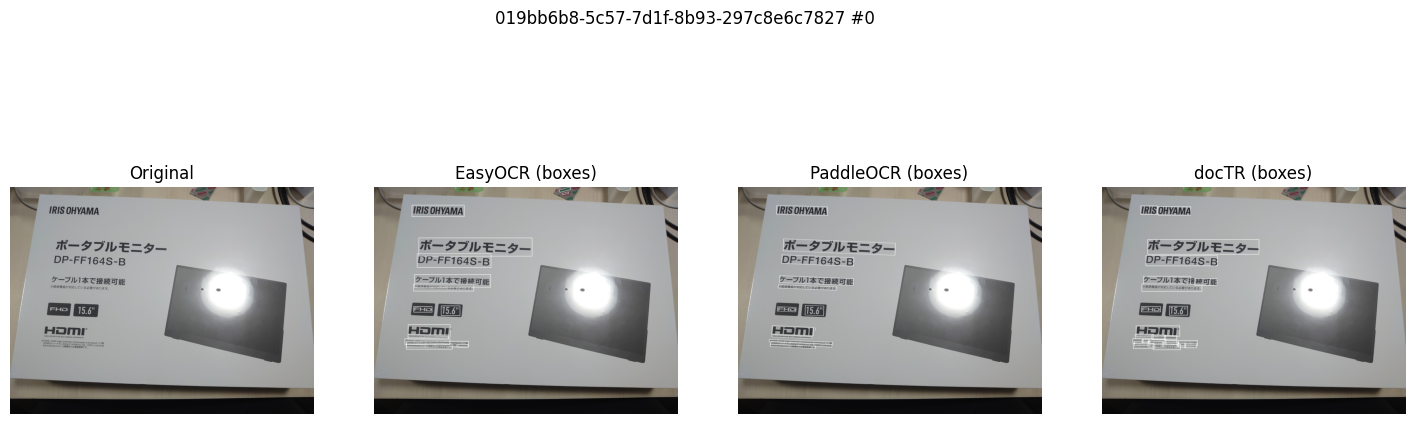


--- EasyOCR text preview ---
 IRISOHYAWA
ポータブルモニター
DP-FF164S-B
ケーブル]本で接続可能
淡接続機器が対応している山要があります。
いP
15.6"
H田
HISH-DEFINITION MULTIMEDIA INTERFACE
※HBMohPM_L-gefinition_Multimedia
Aiiiiostgio eしiる S9州昭留 紀空い幡語
Administratorinc の高績または登録橋禄町す]
Licensing
ロロロロ
エ丁ェさ

--- PaddleOCR text preview ---
 IRIS OHYAMA
ポータブルモニター
DP-FF164S-B
ケーブル1本で接続可能
接続機器が対応している必要があります。
FHD
15.6″
HDMI
?
HIGH-DEFINITION MULTIMEDIAINTERFACE
HDMI、HDMI High-Definition Multimedia Interfaceと語、
HDMIの卜レ-ドドレスおよHDMIのOは、HDMILiCenSing
AdministratorInc.の商標または登録商標です。

--- docTR text preview ---
 IRIS OHYAMA T-971E-S- DP-FF164S-B 5-711xC ITOFE *RHRHDWISLEUBBECCUBBESDET. FHD 15.6" Homr HIGH-DEFINITION MULTIMEDIAI INTERFACE *HDMI, HDMIONL- HDMI FEUZBRU High-Definition HDMODSIE, Multimedial Interfacetu5E. HDMI Administratorinc. ORBEREEBRRCS Licensing

[4/20] messageId=019bb6b8-5c57-7d1f-8b93-297c8e6c7827 image_index=1
message_text (head): ポータブルモニターを購入して、部室に置きました
image_path: /content/traq_images/019bb6b8-5c57-7d1f-8b93-297c8e6c7827_1.p

,engine,seconds,n_items,mean_conf
2,doctr,1.797520,121,0.684428
0,easyocr,11.122131,96,0.575975
1,paddleocr,106.373765,128,0.900809


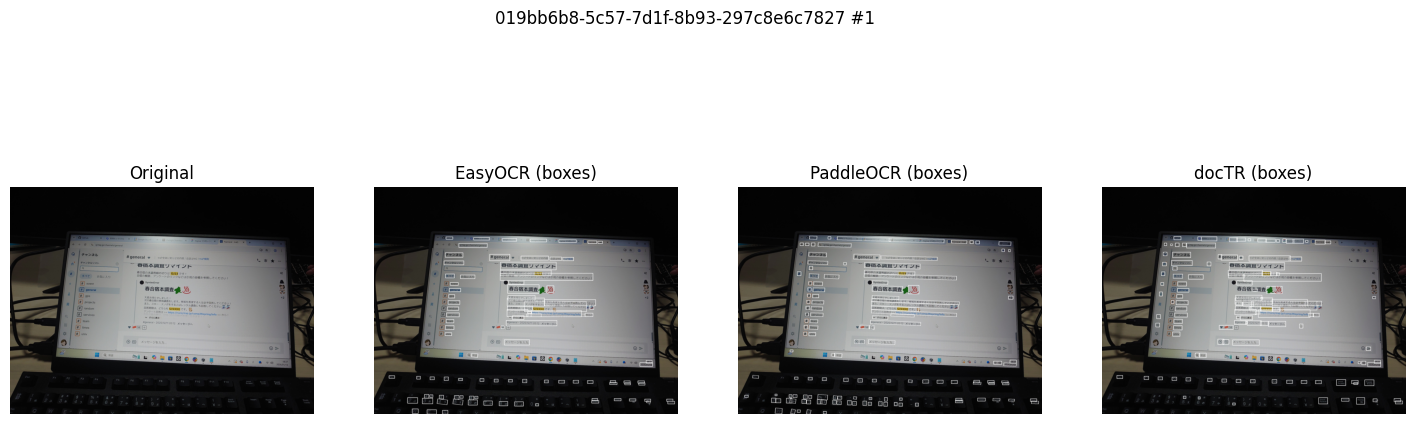


--- EasyOCR text preview ---
 GitHub
頭明チユートリアル -
Goggle カレンリー
DaslightDownloa
Figma: コラボレーショ
#general
tag
qtrapjpichannelsigeneral
チャンネル
#general
tap全体に知らせる内容
会話はNG
taP規則
チャンネルリスト
春-不調食リマイント
養合宿の本調査締め切りは 12123 です !
すべて
お気に入り
合宿の宮要: アンケートのりンうなどは引用の投稲を登照してください !
event
SyntaxError
general
春合宿本調査_
IS》
gps
大変お待たせしました !
projects
まの春会宥の登分計助をしますは
拳加を希望する人はひず回答してください !
random
回答期限は; どちらも
うりもなりるりはしすら 調督毛国答してきとさく
…
アンケート回答は
らう
hitps:llrucq_trapjplcampzGspringlinfo
services
‥いら へハハー
くく
から!
さらに表示
team
#general-2025/12/1120.12 メッセージヘ
times
14
univ
メッセージを入力
18.37
2026/01/13
1s
F1
FF?
F』
FA
F5
F6
F7
F8
F9
FI0
F11
Fi2
Pnint
Sciol
Pzuie
白ereen
一ロは
日ipa
#
ゆ
$$
%
元
8
お
2ふ
3 あ
Bhc
Ingen
noms
pavp
~
6 お
7 や
8 ゆ
9 よ
Snnee
~んち
・
I
じい
1
検索
4う
5 え
~

--- PaddleOCR text preview ---
 GitHub
×
照明チユト×13Googleカダ×
Daslight Downloa×Figma:-×
#general-traQ
×
+
q.trap.jp/channels/general
□×
←
→
C
0
:
チソネ
#general
traP全体知せる内容/会話はNG/traP規則
チャソネリスト
+
春佰本調査リマインド
Q
春合宿の本調査締め切りは12/23です!
#
すべて
お気に入り
合宿の概要、アンケ一トのりンクなどは引用の投稿を参照し

,engine,seconds,n_items,mean_conf
2,doctr,0.760515,21,0.699331
0,easyocr,2.879258,4,0.790451
1,paddleocr,9.055421,3,0.970201


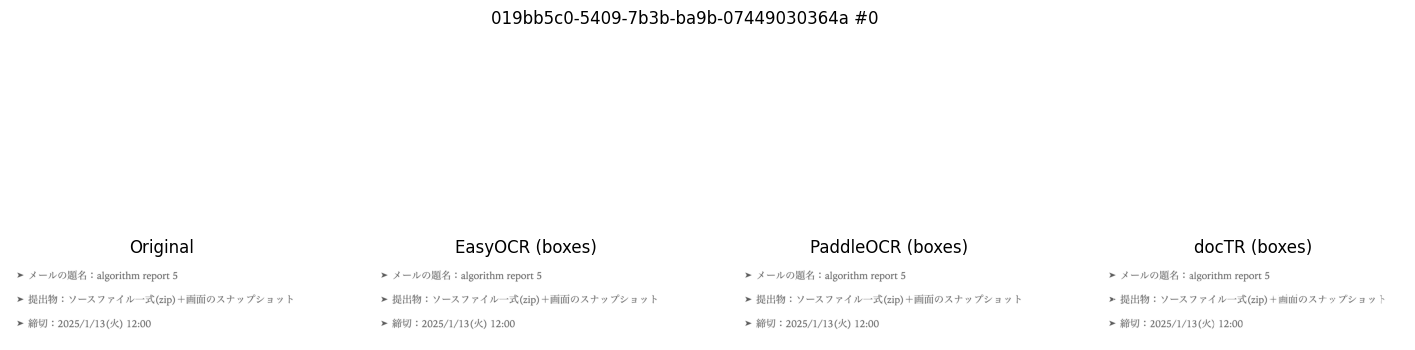


--- EasyOCR text preview ---
 メールの題名
algorithmreport5
提出物: ソースファイルー式(zip)十画面のスナップショット
締切 : 2025/1/13(火)12.00

--- PaddleOCR text preview ---
 メールの題名：algorithm report 5
提出物：ソースファイルー式(zip)＋画面のスナップショット
締切：2025/1/13(火)12:00

--- docTR text preview ---
 X-NOHA : algorithm report 5 - HEHIV : 1-2771-(zip) + HORT -  TVy - N ML : 2025/1/13 (X) 12:00

[6/20] messageId=019bd043-d86c-79b8-9cf1-11351a482267 image_index=0
message_text (head): WSL占有しすぎだなぁ
image_path: /content/traq_images/019bd043-d86c-79b8-9cf1-11351a482267_0.png


,engine,seconds,n_items,mean_conf
2,doctr,1.137681,48,0.864788
0,easyocr,3.444005,26,0.490085
1,paddleocr,22.472994,18,0.879006


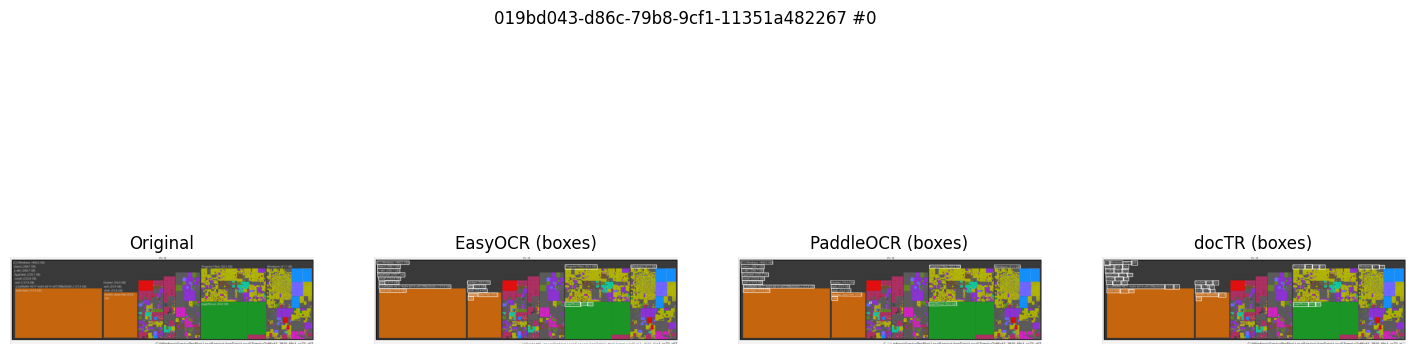


--- EasyOCR text preview ---
 [C] Vindows (460.2 GB)
Usersl{288.7GB)
Program Filesl〔50.3GB)
WNindowsl(41.7 GB)
y-akil(288.7 GB)
AppDatal(250.7GB)
Locall {232.8 GB)
WSI
【137.9GB}
Dockerl(560GB)
{c5a98d46-4617-4c84-6914-e972f8605601(137.9GB)
WSI
【55.9 GB)
ext4vhdx(137.9GB)
diskl(55.8 GB}
docher
datavhdx(55.8
GB)
pagefilesys
GB)
一_【h山一
こ一一 一ロ-一 上 _一】 _ _ 一に_、田一 一}ハ、ロ上一}|
川 す一- _ワ_・_:
つn ざn
d・
{360

--- PaddleOCR text preview ---
 [C:] Windows (460.2 GB)
Users\ (288.7 GB)
ProgramFiles\(50.3GB)
Windows\(41.7GB)
y-aki\ (288.7 GB)
AppData\ (250.7 GB)
Local\ (232.8 GB)
wsl\ (137.9 GB)
Docker\ (56.0 GB)
{c5a98d46-4617-4c84-b914-e972ff8b0560}\(137.9GB)
wsl\ (55.9 GB)
ext4.vhdx (137.9 GB)
disk\(55.8 GB)
docker_data.vhdx (55.8
GB)
2
pagefile.sys (36.0 GB)
小

--- docTR text preview ---
 [C] Windows (460.2 GB) Usersl (288.7 GB) Program Filest (50.3 GB) Windows) (41.7 GB) y-akil (288.7 GB) AppDatal (250.7 GB) Locall (232.8 GB) wsl (137.9 GB) Docker (56.0 GB) (c5a98d46-4617-4c84-b914-e972ff8b0560) (1

,engine,seconds,n_items,mean_conf
0,easyocr,0.262127,3,0.876485
2,doctr,0.658916,7,0.788841
1,paddleocr,3.512789,3,0.975572


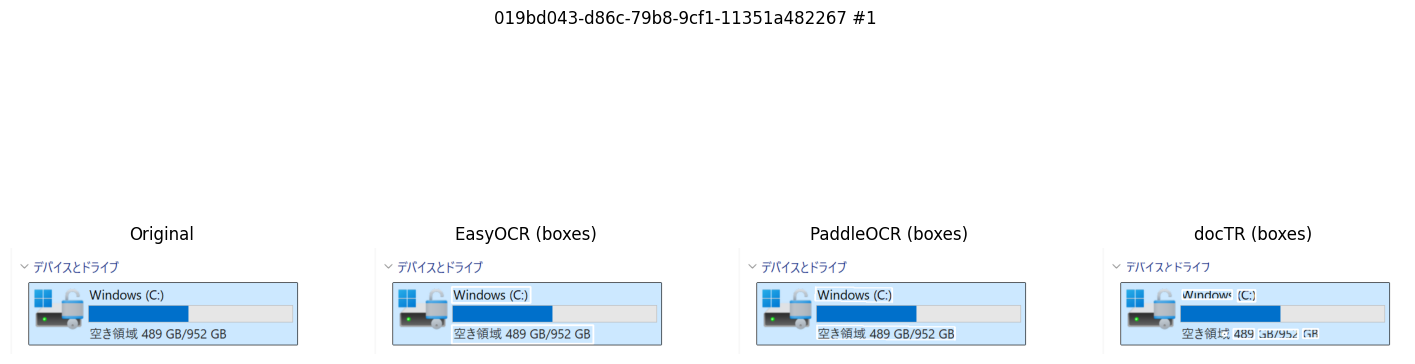


--- EasyOCR text preview ---
 デバイスとドライブ
Vindows (C:)
空き領域 489 GB/952 GB

--- PaddleOCR text preview ---
 デバイスとドライブ
Windows (C:)
空き領域489GB/952 GB

--- docTR text preview ---
 T/1AEF717 Windows (C:) - 489 GB/952 GB

[8/20] messageId=0197c4ef-8be2-792e-922b-c498b6948775 image_index=0
message_text (head): ここのロゴ変えない？
image_path: /content/traq_images/0197c4ef-8be2-792e-922b-c498b6948775_0.png


,engine,seconds,n_items,mean_conf
0,easyocr,0.144325,2,0.815594
2,doctr,0.744021,4,0.915859
1,paddleocr,1.609351,2,0.998962


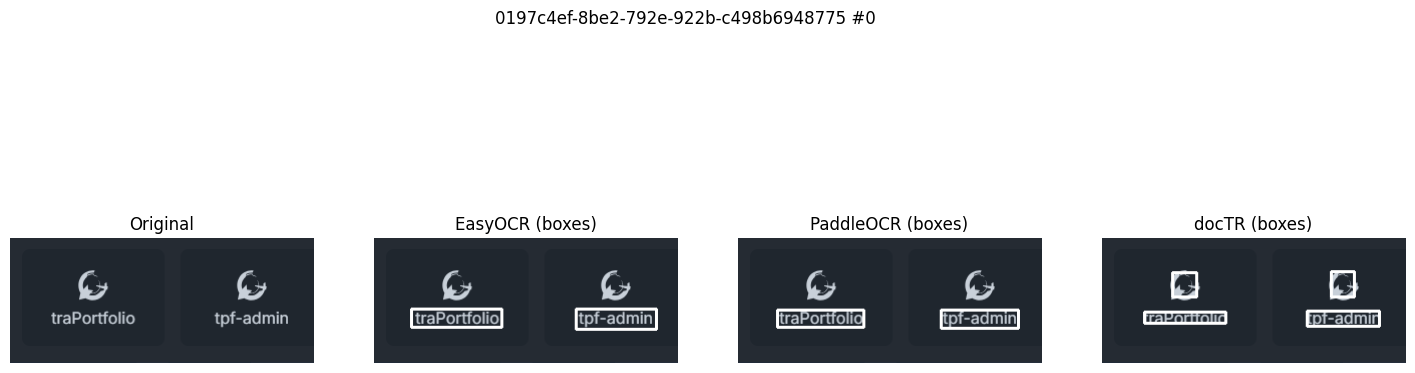


--- EasyOCR text preview ---
 taPorttolio
tpf-admin

--- PaddleOCR text preview ---
 traPortfolio
tpf-admin

--- docTR text preview ---
 1 1 traPortfolio tpf-admin

[9/20] messageId=01963951-0f55-75b5-a53b-07f467ad9051 image_index=0
message_text (head): SysAd体験会、約40人が来てくれて無事実施することができました！ mysql問題は本当にごめんなさい:bow-nya:反省で修正します TAに来てくれた皆様、ありがとうございました！！:thanks-nya:
image_path: /content/traq_images/01963951-0f55-75b5-a53b-07f467ad9051_0.png


,engine,seconds,n_items,mean_conf
2,doctr,0.764623,5,0.609012
0,easyocr,8.235813,8,0.385780
1,paddleocr,12.563372,5,0.735762


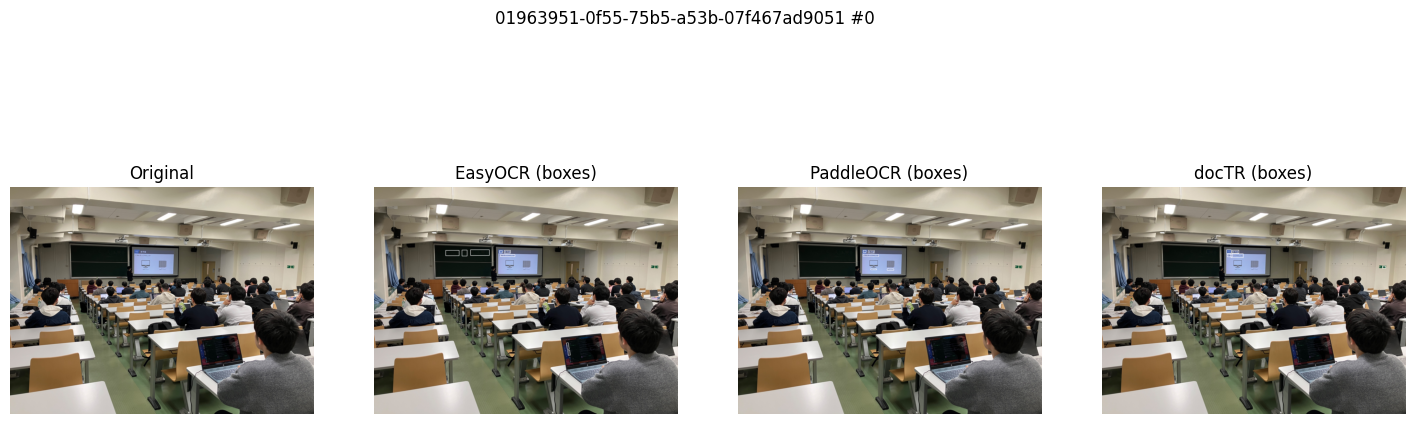


--- EasyOCR text preview ---
 ~
~
~
02
広学1
Web ッービスのしく
@
@

--- PaddleOCR text preview ---
 02
座学编
Webサピの
ETUILO
(

--- docTR text preview ---
 02 EPE Web b4-E2oLCA 1

[10/20] messageId=01963951-0f55-75b5-a53b-07f467ad9051 image_index=1
message_text (head): SysAd体験会、約40人が来てくれて無事実施することができました！ mysql問題は本当にごめんなさい:bow-nya:反省で修正します TAに来てくれた皆様、ありがとうございました！！:thanks-nya:
image_path: /content/traq_images/01963951-0f55-75b5-a53b-07f467ad9051_1.png


,engine,seconds,n_items,mean_conf
2,doctr,0.899842,15,0.555048
0,easyocr,8.771576,12,0.391422
1,paddleocr,23.079894,12,0.832717


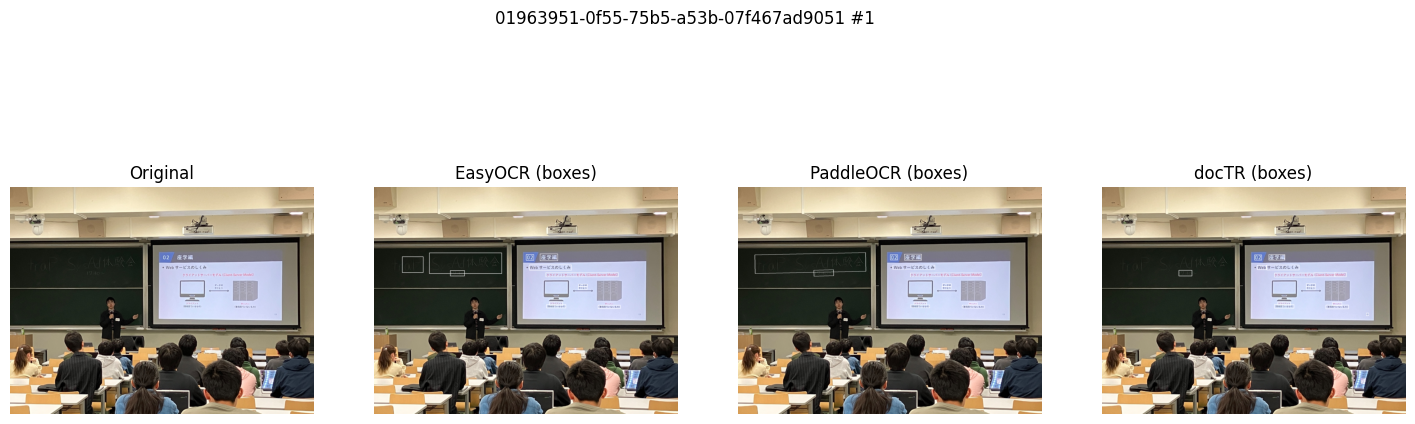


--- EasyOCR text preview ---
 02
座学編
4
こっ代休会
Web サービスのしくみ
7
クライアットサーハーモテル (Cuent SewerilodeU
パータ・
ゆりとり
クうイアット
【川ていくしの)
(m-かいoの)

--- PaddleOCR text preview ---
 traP SysAd体験会
02
座学编
Webサービスのレくみ
17.30~
クラア卜サーバーモデ(Client-Server Model）
データの
やりとり
クライアント
サ一八一
(曾段見ているもの)
(普段見ていないるの)

--- docTR text preview ---
 02 EF Web 4-Ezolra 1730 5517714-K-ETIL (Client-Server Model) F-90 POEY 25177 4-- (BRRTU860) (ERRTIGUGO) 13

[11/20] messageId=01963951-0f55-75b5-a53b-07f467ad9051 image_index=2
message_text (head): SysAd体験会、約40人が来てくれて無事実施することができました！ mysql問題は本当にごめんなさい:bow-nya:反省で修正します TAに来てくれた皆様、ありがとうございました！！:thanks-nya:
image_path: /content/traq_images/01963951-0f55-75b5-a53b-07f467ad9051_2.png


,engine,seconds,n_items,mean_conf
2,doctr,0.855418,6,0.431374
0,easyocr,8.467939,4,0.071406
1,paddleocr,20.729525,11,0.512233


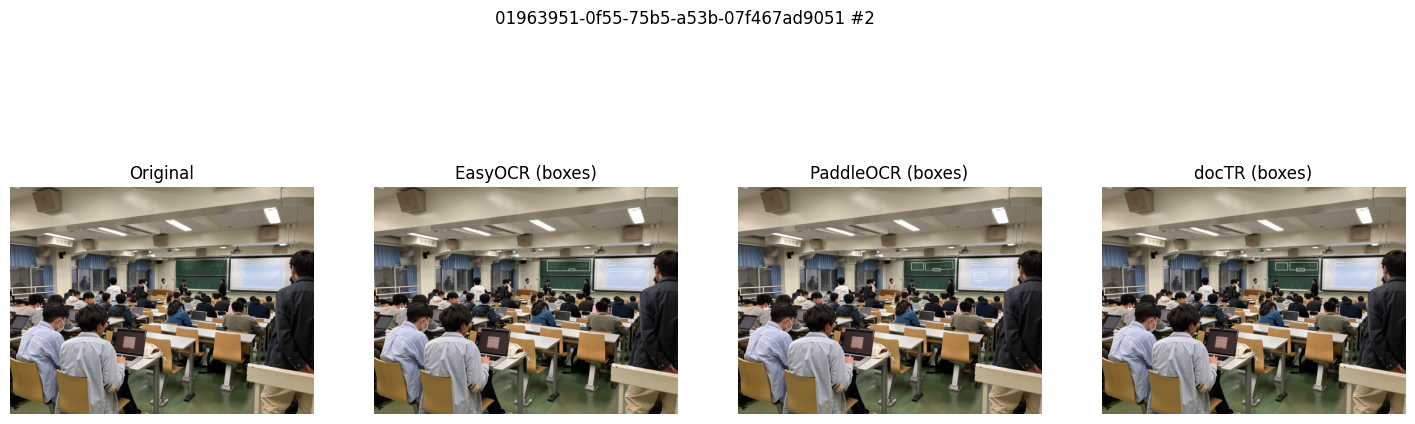


--- EasyOCR text preview ---
 ~
traP SrAl休欧会
山』
おかつだ いこょ |

--- PaddleOCR text preview ---
 
traP
SysAd体験会
実習编
17:30~
分からないことがあったらしましまう
7
2
M

00

--- docTR text preview ---
 HT HEE E traP SYSAJINERA 17:30

[12/20] messageId=0195be37-dea6-7902-8d04-e46185873108 image_index=0
message_text (head): 入れました！ありがとうございます！
image_path: /content/traq_images/0195be37-dea6-7902-8d04-e46185873108_0.png


,engine,seconds,n_items,mean_conf
0,easyocr,0.560065,6,0.903671
2,doctr,0.816153,19,0.828942
1,paddleocr,6.889126,7,0.992704


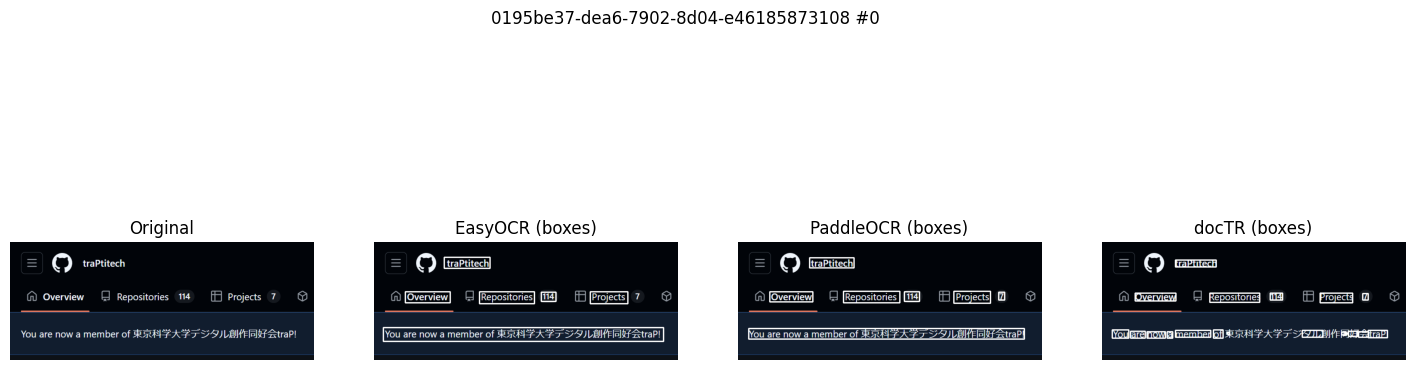


--- EasyOCR text preview ---
 traPtitech
Overview
Repositories
114
Projects
You are now a member叶東京科学大学デジタル創作同好会tap!

--- PaddleOCR text preview ---
 traPtitech
Overview
Repositories
114
Projects
7
Youarenowamemberof東京科学大学デジ夕儿創作同好会traP!

--- docTR text preview ---
 traPtitech Overview Repositories 114 Projects I You are now a member of - yu L - UH H traP!

[13/20] messageId=019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa image_index=0
message_text (head): readme
image_path: /content/traq_images/019bde55-0ca0-7d7a-95ab-0a1c3bf5eeaa_0.png


,engine,seconds,n_items,mean_conf
2,doctr,1.471186,91,0.860336
0,easyocr,8.946058,56,0.792660
1,paddleocr,56.472835,71,0.901850


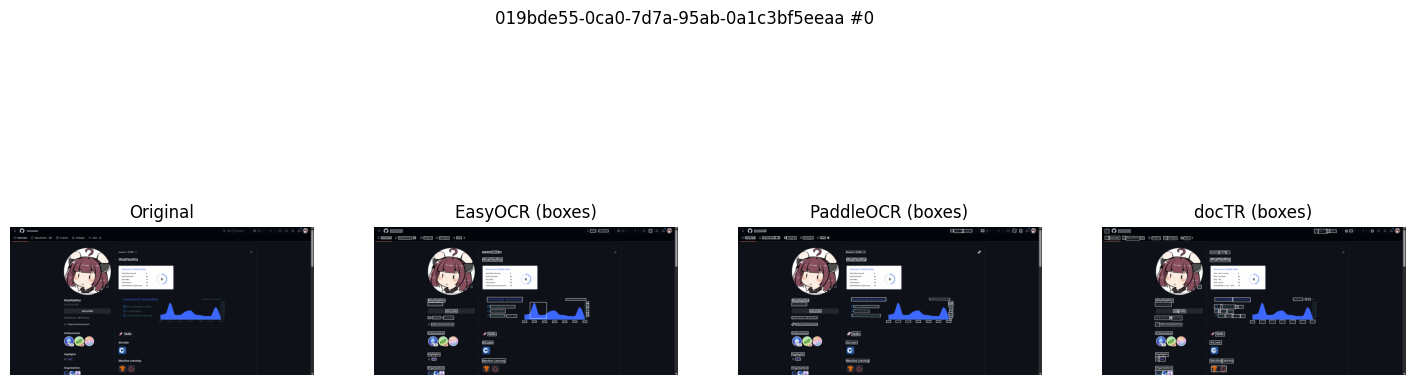


--- EasyOCR text preview ---
 mumumuG
Type
tosearch
8』
Overview
Repositories
25
Projects
Packages
Stars
mumumu6
README
md
mumumu
mumumus GitHub Stats
TotalStars Earned:
TotalCommits:
TotalPRs
Totallssues:
contributedto (lastyear):
mumumu
mumumuG (mumumu)
contributionsinthelast year
450
mumumu6
400
45 Contributionsin2026
350
300
Editprofile
9 Public Repos
八
200
150
Joined GitHub
yearsago
100
91
follower
following
25/01
25/03
25/05
25/07
25/09
25111
26/01
httpsllmumumuGnet
Achievements
skills
989
AtCoder
Highlights
PRO
Machine Learning
Organizations

--- PaddleOCR text preview ---
 Q
Type 
to search
8

mumumu6
口
Overview
Repositories
25
中
Projects
Packages
Stars
4
mumumu6/README.md
0
mumumu
mumumu's GitHub Stats
Total Stars Earned:
6
Total Commits:
2k
Total PRs:
74
B
Total Issues:
30
Contributed to (last year):
10
mumumu6 (mumumu)
mumumu
contributions in the last year
-450
gnwnwnw
-400
45Contributions in 2026
-350
300
Edit profile
9 Public Repos
250
200
-150
 Joined GitHub 4 years ago
1

,engine,seconds,n_items,mean_conf
2,doctr,2.515960,122,0.710656
0,easyocr,10.209999,53,0.856374
1,paddleocr,73.189669,47,0.900866


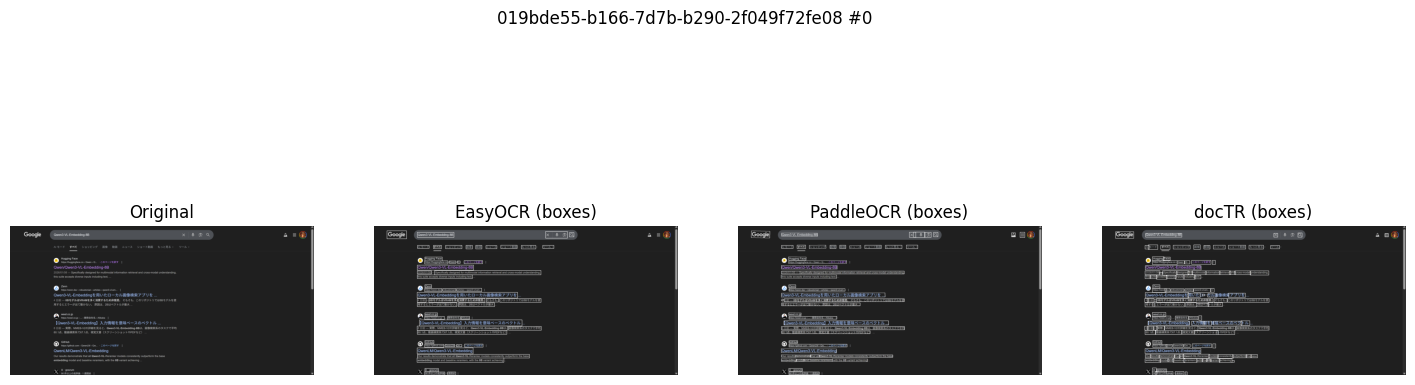


--- EasyOCR text preview ---
 Google
Qwen3-VL-Embedding-8B
メ|  @
a
Aモード
すべて
ショッピング
画像
動画
ニュース
ショート動画
もっと見る
ツール -
Hugging Face
htpsllhuggingface_co
Qwen
Q
このページを訳す
QwenlQwen3-VL-Embedding-8B
2026/01/08
Specifically designedformultimodalinformation retrievaland cross-modalunderstanding;
this suite accepts diverseinputs including text
Zenn
https llzenn_dev
robustonian
articles, qwen3-vl-em 
Qwen3-VL-Embeddingを用いたローカル画像検索アプリを
4 日前
8モデルはV尺AMを多
消費するため非推奨。
そもそも
このリポジトリでは昭モデルを使
用するとエラーが出て動かない。
原因は 2Bはべクトルが最大
weelcojp
https llweelcojp
開発会社名
Alibaba
【Qwen3-VL-Embedding】 入力情報を意味ベースのベクトル
8 日前一実際 MMEB-V2の群細を見ると Qwen3-VL-Embedding-8は
画像検索系のタスクで平均
80.1点 動画検索系で671点 視覚文書 (スクリーンショットヤPDFなど)
GitHub
htps llgithub_com
QwenLM
QW ‥
このページを訳す
QwenLMQwen3-VL-Embedding
Ourresults demonstrate thatallQwen3-VL-Rerankermodels consistently outperorm t

--- PaddleOCR text preview ---
 Google
Qwen3-VL-Embedding-8B
×
中
点
Q
▲
🙌
AIモード
すべて
ショッピング
画像
動画
ニュース
ショート動画
もっと見る▼
ツール
Hugging Face
😜
https://huggingface.co>Qwen>Q...・

,engine,seconds,n_items,mean_conf
2,doctr,0.763247,18,0.756282
0,easyocr,2.656772,8,0.335852
1,paddleocr,15.303584,11,0.833034


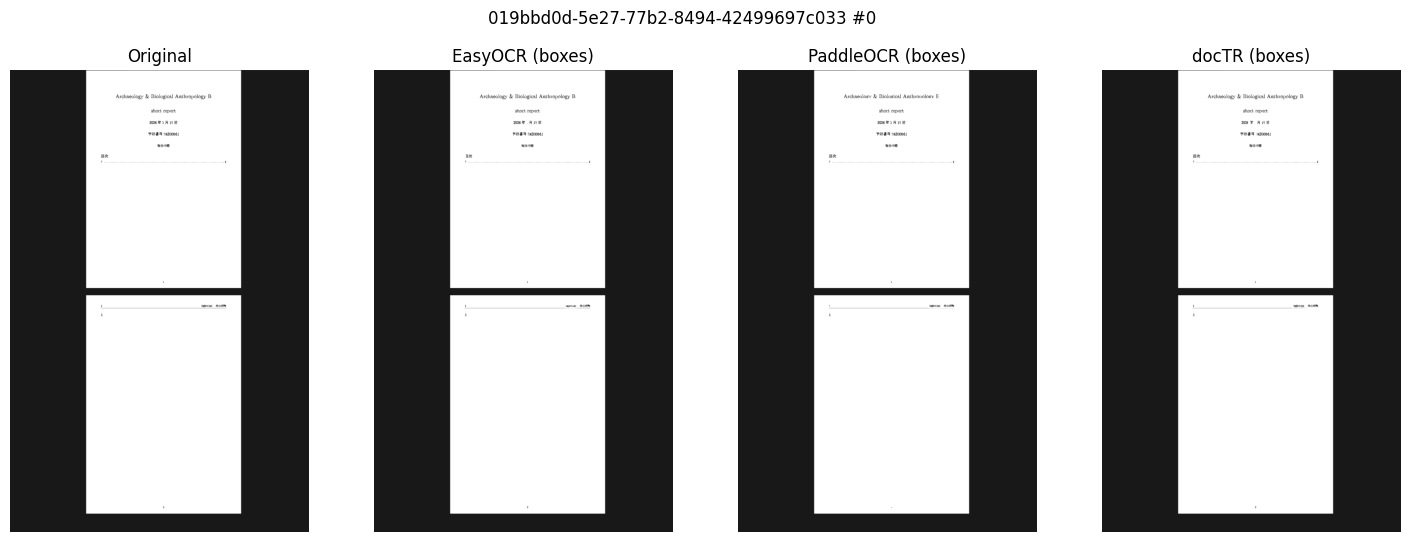


--- EasyOCR text preview ---
 Archaeology & Biologici] Anthronology B
short report
2076 年
月1日
そ縮岳弓 "B30561
佐問所性
弓次
?+5; 川"

--- PaddleOCR text preview ---
 Archaeology & Biological Anthropology B
short report
2026年1月15日
学籍番号24B30561
佐藤巧陛
目次
1
24B0581
作巧
1
H

--- docTR text preview ---
 Archaeology & Biological Anthropology B short report 2026 #1 1H 15 E *RE 24B30561 #INSH EXX 24B0041 (ketpit

[16/20] messageId=019bde84-1609-7dc5-b8fc-f2c77bcdb005 image_index=0
image_path: /content/traq_images/019bde84-1609-7dc5-b8fc-f2c77bcdb005_0.png


,engine,seconds,n_items,mean_conf
2,doctr,1.016694,34,0.466536
0,easyocr,6.590393,32,0.149210
1,paddleocr,27.988480,28,0.734751


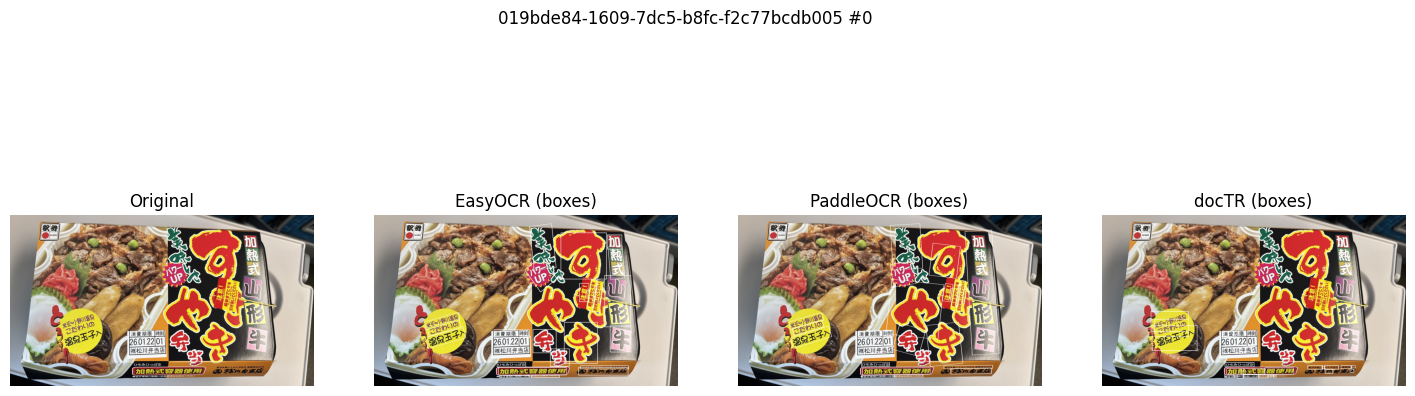


--- EasyOCR text preview ---
 {長
ENIEEM
加
@}
谷
邑
犬
言
消費期T刻
國,
勇
愚
貯
ひもをひっぱる
留
杜羽本線とともに百永年 剤業明治3名年
かw式寄景周
つ未め 多
町つ内に川ぼしりたえ
つーーう・心き・ブニール
!
j
路
』
@
7
昌
言
言
米小野川温
こだわりの
'温泉玉子入

--- PaddleOCR text preview ---
 駅行
茶
加越式山形牛
EKIBEN
C
ハU
や
最後までヒモを
引き抜いてください!
注意！
rerae
pueemn
Pullout the string
米沢·小野川温泉
依
き
こだわいの
消费期限
時刻
温泉玉子入
26.01.22|01
（株）松川弁当店
ひもをひつぱる
奥羽本線とともに百余年創業明治32年
加熱式容器使用
杨川弁当店
必ず事前に取扱い注意
事項をお読みくさい

--- docTR text preview ---
 X t EKIBEN I - R NGMPUSO EE EB Centio # 26.01.2201 29237 *TAJIE L 0620p13 NRE A SEERE HHIAS 24 SIE REEE ETXEZRE JU L  E RuE HRIRCIEER FIRE 4 35 *

[17/20] messageId=019bdeb4-6ec8-7e0e-b773-3bec85c35584 image_index=0
message_text (head): :orenokachi:
image_path: /content/traq_images/019bdeb4-6ec8-7e0e-b773-3bec85c35584_0.png


,engine,seconds,n_items,mean_conf
2,doctr,0.738557,7,0.834894
0,easyocr,5.590525,5,0.748946
1,paddleocr,11.435387,8,0.927652


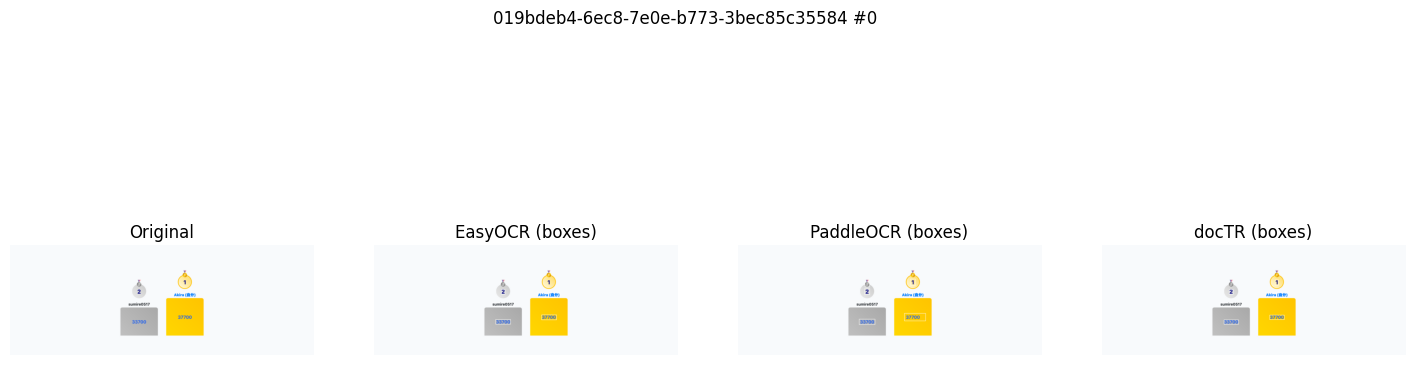


--- EasyOCR text preview ---
 2
Akira 【自分)
sumire0517
37700
33700

--- PaddleOCR text preview ---
 V
1
②
2
Akira (自分)
sumire0517
37700
33700

--- docTR text preview ---
 1 2 Akira (E) sumire0517 37700 33700

[18/20] messageId=019bdeb4-6ec8-7e0e-b773-3bec85c35584 image_index=1
message_text (head): :orenokachi:
image_path: /content/traq_images/019bdeb4-6ec8-7e0e-b773-3bec85c35584_1.png


,engine,seconds,n_items,mean_conf
2,doctr,1.254661,44,0.653007
0,easyocr,2.058599,29,0.621482
1,paddleocr,25.533845,30,0.935630


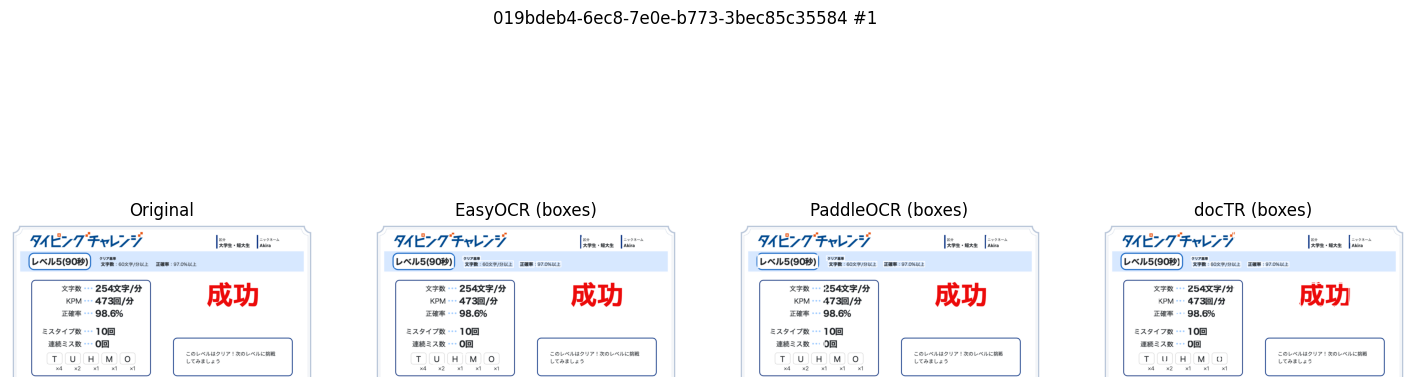


--- EasyOCR text preview ---
 タイピンク チャレンジ
父生
短大生
Awbネ-ム
クリア基準
レベル5(9の秘)
文字数 ; 60文字ノ分以上
正確寧
97.0%以上
文字数
254文字川
KPM
473回川分
成功
正確率
g8.6%
ミスタイプ数
1の回
連続三ス数
の
このレベルはクリア
次のレベルに桃戦
T
u
HJLM
0
してみましょう
x4♪ x2  x1  x1
x1

--- PaddleOCR text preview ---
 タイピンクチヤレノヅ
区分
ニックネーム
大学生·短大生
Akira
レベル5(90秒)
クリア基準
文字数：60文字/分以上
正確率：97.0%以上
成功
文字数
254文字/分
KPM··
473回/分
正確率· 98.6%
ミスタイプ数…・10回
連続ミス数・・
0回
このレベルはクリア!次のレベルに挑戦
T
Ｕ
H
M
o
してみましょう
×4
×2
×1
×1
×1

--- docTR text preview ---
 SAE/TTIL/ X$ Eyb*-4 *T* - AXE Akira 7U7H# LAJL5(90P) XFK : 60XF19LE IEMEEE : 97.0%LE X7X 254X7/9 KPM : o 4730/7 51 IETEX - o 98.6% ER5178 100 EMEXX 0 A COLNLE7UT! ROLAJLEBEX T U H M O CTA*L* x4 x2 x1 x1 x1

[19/20] messageId=019bb65e-9263-7c89-b123-95389f4414cd image_index=0
message_text (head): マンションの玄関抜けたら猫にガン見されてた
image_path: /content/traq_images/019bb65e-9263-7c89-b123-95389f4414cd_0.png


,engine,seconds,n_items,mean_conf
2,doctr,0.727971,0,0.0
0,easyocr,4.373004,0,0.0
1,paddleocr,5.637351,1,0.0


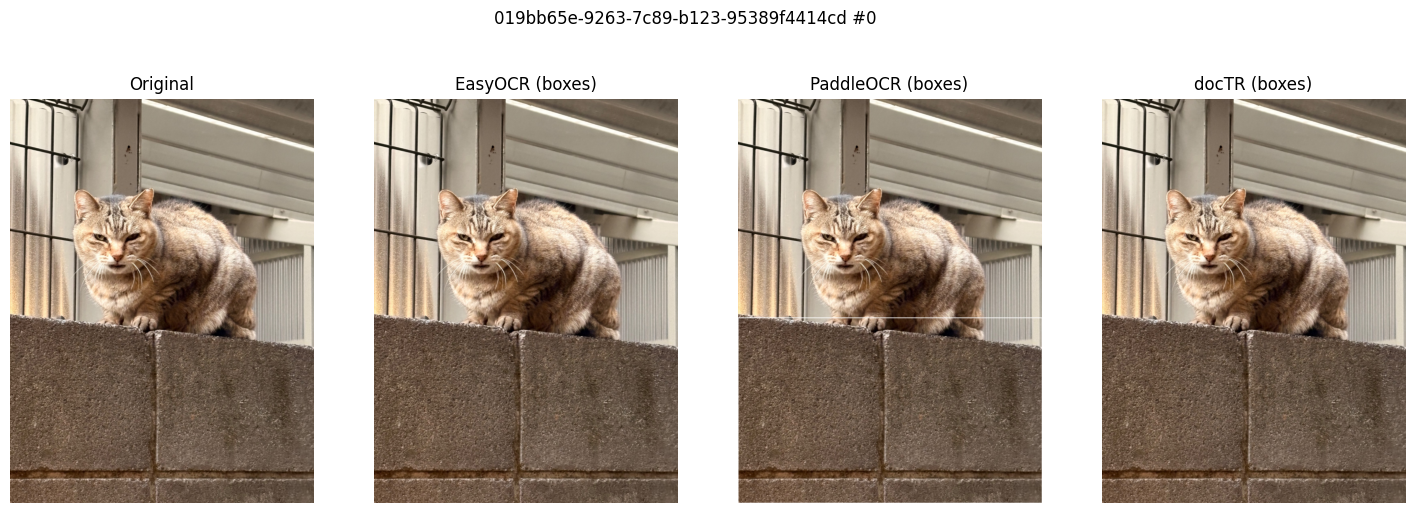


--- EasyOCR text preview ---
 

--- PaddleOCR text preview ---
 

--- docTR text preview ---
 

[20/20] messageId=019b8cea-695d-7047-aafb-793c58d25eff image_index=0
message_text (head): いまちょっとくねくねしてる
image_path: /content/traq_images/019b8cea-695d-7047-aafb-793c58d25eff_0.png


,engine,seconds,n_items,mean_conf
2,doctr,1.101999,32,0.909474
0,easyocr,2.515433,18,0.722952
1,paddleocr,19.204933,26,0.959571


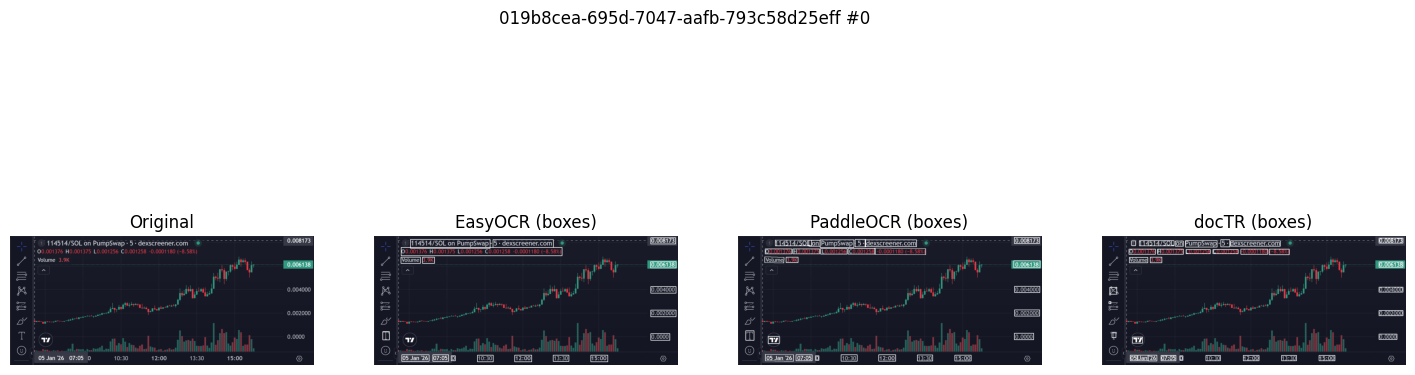


--- EasyOCR text preview ---
 114514/SOLon PumpSwap
5'dexscreenercom
0.008173
00.001376 H0.001375 L0.001256 C0.001258-0.0001180 (-8.58%)
Volume
3.9K
0.006138
0.0O4OO0
O.OOzoO0
T
Ooooo
05 Jan '26
07:05
0
10.30
12.00
13.30
15.00

--- PaddleOCR text preview ---
 0.008173
114514/SOL
ōn
PumpSwap
5%
dexscreēner.cōm
00.001376
H0.001375
L0.001256
C0.001258
-0.0001180 (-8.58%)
Volume
3.9K
0.006138
0.004000
0.002000
T
0.0000
7
05 Jan '26
07:05
0
10:30
12:00
13:30
15:00

--- docTR text preview ---
 1 114514/SOL on PumpSwap 5. dexscreener.com 0.008173 00.001376 H0.001375 L0.001256 C0.001258 -0.0001180 (-8.58%) Volume 3.9K 0.006138 K 0.004000 o 0.002000 I 0.0000 T 05 Jan '26 07:05 0 10:30 12:00 13:30 15:00

Saved: /content/traq_ocr_compare_results.json


In [7]:
# %% [C] Run & compare (matplotlib)
from typing import List, Dict, Any, Tuple

def pil_open_rgb(path: str) -> Image.Image:
    return Image.open(path).convert("RGB")

def poly_to_bbox(poly: List[List[float]]) -> Tuple[float,float,float,float]:
    xs = [p[0] for p in poly]
    ys = [p[1] for p in poly]
    return (min(xs), min(ys), max(xs), max(ys))

def draw_polys(img: Image.Image, items: List[Dict[str,Any]], max_polys: int = 200) -> Image.Image:
    out = img.copy()
    d = ImageDraw.Draw(out)
    for it in items[:max_polys]:
        poly = it["poly"]
        # poly: [[x,y],...]
        d.line(poly + [poly[0]], width=3)
    return out

def run_easyocr(image_path: str) -> Dict[str, Any]:
    t0 = time.perf_counter()
    out = easy_reader.readtext(image_path)  # [[bbox4pts], text, conf]
    dt = time.perf_counter() - t0

    items = []
    for bbox, text, conf in out:
        poly = [[float(x), float(y)] for x, y in bbox]
        items.append({
            "text": text,
            "conf": float(conf),
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })
    full_text = "\n".join([it["text"] for it in items])
    mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
    return {"engine": "easyocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}

import json, time
import numpy as np

def _to_py(x):
    return x.tolist() if hasattr(x, "tolist") else x

def _parse_paddle_v3(pred_result):
    # pred_result: list[Result] っぽい。Result.json が dict を返す想定。
    if isinstance(pred_result, (list, tuple)) and len(pred_result) > 0:
        r0 = pred_result[0]
    else:
        r0 = pred_result

    # dict化
    if hasattr(r0, "json"):
        data = r0.json
    elif isinstance(r0, dict):
        data = r0
    else:
        # 最後の手段：print用の文字列などが来たら厳しいので例外
        raise TypeError(f"Unexpected PaddleOCR v3 result type: {type(r0)}")

    if isinstance(data, str):
        data = json.loads(data)

    # 例: {"res": {...}} の形
    if "res" in data and isinstance(data["res"], dict):
        data = data["res"]

    texts  = data.get("rec_texts", []) or []
    scores = _to_py(data.get("rec_scores", [])) or []
    polys  = _to_py(data.get("rec_polys", None)) or _to_py(data.get("dt_polys", None))

    items = []
    if polys is None:
        return items

    for i, t in enumerate(texts):
        if i >= len(polys):
            break
        poly = polys[i]  # [[x,y]x4]
        conf = float(scores[i]) if i < len(scores) else 0.0
        poly = [[float(x), float(y)] for x, y in poly]
        items.append({
            "text": t,
            "conf": conf,
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })
    return items

def run_paddle(image_path: str) -> Dict[str, Any]:
    t0 = time.perf_counter()

    # --- v3優先: predict ---
    if hasattr(paddle_ocr, "predict"):
        try:
            pred = paddle_ocr.predict(image_path)
            dt = time.perf_counter() - t0
            items = _parse_paddle_v3(pred)

            full_text = "\n".join([it["text"] for it in items if it["text"] is not None])
            mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
            return {"engine": "paddleocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}
        except TypeError:
            # v2っぽい戻り値/挙動なら下へ
            pass

    # --- v2: ocr(cls=...) ---
    try:
        result = paddle_ocr.ocr(image_path, cls=True)
    except TypeError:
        result = paddle_ocr.ocr(image_path)

    dt = time.perf_counter() - t0

    lines = result[0] if (result and len(result) > 0) else []
    items = []
    for line in lines:
        poly = [[float(x), float(y)] for x, y in line[0]]
        text, conf = line[1]
        items.append({
            "text": text,
            "conf": float(conf),
            "poly": poly,
            "bbox": list(map(float, poly_to_bbox(poly))),
        })

    full_text = "\n".join([it["text"] for it in items])
    mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
    return {"engine": "paddleocr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}
    
def run_doctr(image_path: str) -> Dict[str, Any]:
    img = pil_open_rgb(image_path)
    W, H = img.size

    t0 = time.perf_counter()
    doc = DocumentFile.from_images(image_path)
    res = doctr_ocr(doc)
    dt = time.perf_counter() - t0

    items = []
    page = res.pages[0]
    for block in page.blocks:
        for line in block.lines:
            for w in line.words:
                (x0, y0), (x1, y1) = w.geometry  # normalized
                poly = [[x0*W, y0*H], [x1*W, y0*H], [x1*W, y1*H], [x0*W, y1*H]]
                items.append({
                    "text": w.value,
                    "conf": float(w.confidence),
                    "poly": poly,
                    "bbox": [x0*W, y0*H, x1*W, y1*H],
                })
    full_text = " ".join([it["text"] for it in items]).strip()
    mean_conf = float(np.mean([it["conf"] for it in items])) if items else 0.0
    return {"engine": "doctr", "seconds": dt, "items": items, "full_text": full_text, "mean_conf": mean_conf}

def show_compare(image_path: str, r_easy, r_pad, r_doc, title: str = ""):
    base = pil_open_rgb(image_path)

    im_easy = draw_polys(base, r_easy["items"])
    im_pad  = draw_polys(base, r_pad["items"])
    im_doc  = draw_polys(base, r_doc["items"])

    plt.figure(figsize=(18, 6))
    for i, (im, name) in enumerate([(base, "Original"),
                                    (im_easy, "EasyOCR (boxes)"),
                                    (im_pad, "PaddleOCR (boxes)"),
                                    (im_doc, "docTR (boxes)")], start=1):
        plt.subplot(1, 4, i)
        plt.imshow(im)
        plt.title(name)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.show()

# 実行する枚数（多いと重いので必要なら制限）
MAX_IMAGES = 20
targets = records[:MAX_IMAGES]

all_results = []

for k, rec in enumerate(targets, start=1):
    path = rec["image_path"]
    mid  = rec["messageId"]
    idx  = rec["image_index"]
    msg  = rec["message_text"]

    print("\n" + "="*70)
    print(f"[{k}/{len(targets)}] messageId={mid} image_index={idx}")
    if msg:
        print("message_text (head):", msg[:120].replace("\n", " "))
    print("image_path:", path)

    r_easy = run_easyocr(path)
    r_pad  = run_paddle(path)
    r_doc  = run_doctr(path)

    # summary table
    df = pd.DataFrame([
        {"engine": r_easy["engine"], "seconds": r_easy["seconds"], "n_items": len(r_easy["items"]), "mean_conf": r_easy["mean_conf"]},
        {"engine": r_pad["engine"],  "seconds": r_pad["seconds"],  "n_items": len(r_pad["items"]),  "mean_conf": r_pad["mean_conf"]},
        {"engine": r_doc["engine"],  "seconds": r_doc["seconds"],  "n_items": len(r_doc["items"]),  "mean_conf": r_doc["mean_conf"]},
    ]).sort_values("seconds")
    display(df)

    # matplotlib compare
    show_compare(path, r_easy, r_pad, r_doc, title=f"{mid} #{idx}")

    # text previews
    print("\n--- EasyOCR text preview ---\n", r_easy["full_text"][:800])
    print("\n--- PaddleOCR text preview ---\n", r_pad["full_text"][:800])
    print("\n--- docTR text preview ---\n", r_doc["full_text"][:800])

    all_results.append({
        "record": rec,
        "easyocr": r_easy,
        "paddleocr": r_pad,
        "doctr": r_doc,
    })

# 保存（任意）
OUT_JSON = "/content/traq_ocr_compare_results.json"
with open(OUT_JSON, "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print("\nSaved:", OUT_JSON)